In [1]:
import numpy as np
from scipy.io import loadmat, savemat
import os

dy = 100e3
dz = 100.0
dt = 20 * 24 * 3600
T = 1000 * (12 * 30 * 24 * 3600)
l = 2e6
H = 4e3
Ly = 15e6
Lx = 6e6
Kv = 2e-5
Kc = 1e3
f = 1e-4
lambda_ = 1 / (30 * 24 * 3600)
Keddy = 1000.0
bvp_cmin = 0.1
bvp_mode = 2
do_load = False
do_save = True
fnameIN = "out.mat"
fnameOUT = "out.mat"

params = {
    "dy": dy,
    "dz": dz,
    "dt": dt,
    "T": T,
    "l": l,
    "H": H,
    "Ly": Ly,
    "Lx": Lx,
    "Kv": Kv,
    "Kc": Kc,
    "f": f,
    "lambda": lambda_,
    "Keddy": Keddy,
    "bvp_cmin": bvp_cmin,
    "bvp_mode": bvp_mode,
    "do_load": do_load,
    "do_save": do_save,
    "fnameIN": fnameIN,
    "fnameOUT": fnameOUT,
}

if do_load and os.path.exists(fnameIN):
    try:
        data = loadmat(fnameIN)
        params.update(data)
    except Exception:
        pass

if do_save:
    savemat(fnameOUT, params)


In [2]:
nt = T / dt
ny = l / dy
nz = H / dz

nyb = Ly / dy
nyt = ny + nyb

rdy = 1 / dy
rdz = 1 / dz

yb = np.arange(-l + dy/2, Ly, dy)
zb = np.arange(-H + dz/2, -dz/2 + dz, dz)

yp = np.arange(-l + dy, Ly + dy, dy)
zp = np.arange(-H + dz, 0 + dz, dz)

YB, ZB = np.meshgrid(yb, zb)
YP, ZP = np.meshgrid(yp, zp)

In [3]:
bs = 15 * (1 + yb[:int(ny)] / l) * 2e-4 * 10
bn = (1.5 - 15 / l * (yb[int(ny):] - Ly)) * 2e-4 * 10

wind = (-0.1 / 1e3 / f) * np.sin(np.pi / 2 * (1 + yp[:int(ny)] / l))[:, None] * np.ones((1, int(nz)))

kv0 = Kv * np.ones(int(nz))

In [4]:


b = np.zeros((int(ny), int(nz)))
p = np.zeros((int(ny), int(nz)))

B = np.zeros((int(nyt), int(nz)))
P = np.zeros((int(nyt), int(nz)))

by = np.zeros((int(ny), int(nz)))
bz = np.zeros((int(ny), int(nz)))

By = np.zeros((int(ny), int(nz)))
Bz = np.zeros((int(ny), int(nz)))

v = np.zeros((int(ny), int(nz)))
w = np.zeros((int(ny), int(nz)))

Aud = np.zeros((int(ny), int(nz)))
Ans = np.zeros((int(ny), int(nz)))
DIV = np.zeros((int(ny), int(nz)))
RHS = np.zeros((int(ny), int(nz), 3))

TIME = []
NADW = []
AABW = []

if do_load:
    try:
        data = loadmat(fnameIN)
        if "b" in data:
            b = data["b"]
        if "RHS" in data:
            RHS = data["RHS"]
    except Exception:
        pass


In [5]:
alpha = dz * dz / dt

aa = np.concatenate(([0], kv0[:int(nz)-1]))
cc = kv0
bb = -(alpha + aa + cc)

E0 = np.diag(bb)
E0 += np.diag(aa[1:int(nz)], k=-1)
E0 += np.diag(cc[:int(nz)-1], k=1)

E0[0, 0] = -(alpha + kv0[0])
E0[int(nz)-1, int(nz)-1] = -(alpha + kv0[int(nz)-2])

E0 = np.linalg.inv(E0)

for t in range(1, int(nt) + 1):
    by[:int(ny)-1, :] = (b[1:int(ny), :] - b[:int(ny)-1, :]) * rdy
    by[int(ny)-1, :] = 0

    bz[:, :int(nz)-1] = (b[:, 1:int(nz)] - b[:, :int(nz)-1]) * rdz
    bz[:, int(nz)-1] = 0


In [6]:
By[:, :int(nz)-1] = 0.5 * (by[:, :int(nz)-1] + by[:, 1:int(nz)])
By[:, int(nz)-1] = 0

Bz[:int(ny)-1, :] = 0.5 * (bz[:int(ny)-1, :] + bz[1:int(ny), :])
Bz[int(ny)-1, :] = 0

p = Keddy * By

c = np.sum(np.sqrt(Bz) * dz, axis=1) / (np.pi * bvp_mode)
c = np.maximum(np.real(c), bvp_cmin)
c = (c / dz) ** 2

for n in range(int(ny) - 1):
    aa = c[n] * np.ones(int(nz))
    bb = -(2 * c[n] + Bz[n, :])
    cc_row = c[n] * np.ones(int(nz))

    E = np.diag(bb)
    E += np.diag(aa[1:int(nz)], k=-1)
    E += np.diag(cc_row[:int(nz)-1], k=1)

    r = p[n, :].copy()

    r[0] = r[0] - c[n] * wind[n, 0]

    E[int(nz)-1, int(nz)-2:int(nz)] = [0, 1]
    r[int(nz)-1] = wind[n, int(nz)-1]

    p[n, :] = np.linalg.solve(E, r)

p = -wind + p

p[int(ny)-1, :] = 0


In [7]:
Bbasin = np.ones((int(nyb), 1)) * b[int(ny)-1, :]

BB = np.tile(bn[:, None], (1, int(nz)))
Bbasin = np.minimum(Bbasin, BB)

BB[:int(nyb)-1, :] = (Bbasin[1:int(nyb), :] - Bbasin[:int(nyb)-1, :]) * rdy
BB[int(nyb)-1, :] = 0

if b[int(ny)-1, int(nz)-1] != 0:
    znadw = np.interp(bn[-1], b[int(ny)-1, :], zb)
else:
    znadw = -1

u = np.fliplr(np.cumsum(np.fliplr(BB) * dz, axis=1)) / f
u = np.hstack([u[:, 1:], np.zeros((int(nyb), 1))])

u0 = np.interp(znadw, zp, u[int(ny)-1, :])
u = u - u0

nnadw = np.where(zp >= znadw)[0]

U = 0.5 * (u[:, nnadw[:-1]] + u[:, nnadw[1:]])
U = np.sum(U * dz, axis=1)

if znadw != zp[nnadw[0]]:
    U += 0.5 * u[:, nnadw[0]] * (zp[nnadw[0]] - znadw)

U = U / (-znadw)

u = u - U[:, None]

U = np.fliplr(np.cumsum(np.fliplr(0.5 * (u[:, :-1] + u[:, 1:]) * dz), axis=1))
U = np.hstack([U, np.zeros((int(nyb), 1))])

U = 0.5 * (U[:-1, :] + U[1:, :])
U = np.flipud(np.cumsum(np.flipud(U) * dy, axis=0))
U = np.vstack([U, np.zeros((1, int(nz)))])
U[:, zp < znadw] = 0

U = U / Lx

p[int(ny)-1, :] = U[0, :]


In [8]:
v[:, 0] = -p[:, 0] * rdz
v[:, 1:int(nz)] = -(p[:, 1:int(nz)] - p[:, :int(nz)-1]) * rdz

w[0, :] = p[0, :] * rdy
w[1:int(ny), :] = (p[1:int(ny), :] - p[:int(ny)-1, :]) * rdy

Ans[:int(ny)-1, :] = v[:int(ny)-1, :] * b[1:int(ny), :]
Ans[v > 0] = v[v > 0] * b[v > 0]
Ans[int(ny)-1, :] = v[int(ny)-1, :] * b[int(ny)-1, :]

Aud[:, :int(nz)-1] = w[:, :int(nz)-1] * b[:, 1:int(nz)]
Aud[w > 0] = w[w > 0] * b[w > 0]
Aud[:, int(nz)-1] = 0

DIV[0, :] = Ans[0, :] * rdy
DIV[1:int(ny), :] = (Ans[1:int(ny), :] - Ans[:int(ny)-1, :]) * rdy

DIV[:, 0] += Aud[:, 0] * rdz
DIV[:, 1:int(nz)] += (Aud[:, 1:int(nz)] - Aud[:, :int(nz)-1]) * rdz

RHS[:, :, 2] = -DIV

b = b + dt * (1.5 * RHS[:, :, 2] - 0.5 * RHS[:, :, 1])

RHS[:, :, 0] = RHS[:, :, 1].copy()
RHS[:, :, 1] = RHS[:, :, 2].copy()


In [9]:
sflux = -dz * lambda_ * (bs - b[:, int(nz)-1])

for n in range(int(ny)):
    E = E0.copy()

    nn = np.where(bz[n, :] < 0)[0]

    if nn.size > 0 or n == int(ny) - 1:
        if n == int(ny) - 1:
            kv = kv0 * Ly / dy
        else:
            kv = kv0.copy()

        kv[nn] = Kc

        aa = np.concatenate(([0], kv[:int(nz)-1]))
        cc = kv
        bb = -(alpha + aa + cc)

        E = np.diag(bb)
        E += np.diag(aa[1:int(nz)], k=-1)
        E += np.diag(cc[:int(nz)-1], k=1)

        E[0, 0] = -(alpha + kv[0])
        E[int(nz)-1, int(nz)-1] = -(alpha + kv[int(nz)-2])

        E = np.linalg.inv(E)

    r = -alpha * b[n, :]
    r[int(nz)-1] += sflux[n] * dz
    b[n, :] = E @ r


In [10]:
TIME.append(t * dt)
NADW.append(np.max(p[int(ny)-1, :]) * Lx * 1e-6)
AABW.append(np.min(p[int(ny)-2, :]) * Lx * 1e-6)

print(f'Completed: {round(100*t/nt)}% NADW: {NADW[-1]:4.2f} AABW: {AABW[-1]:4.2f}')

B = np.vstack([b, Bbasin])

nn = np.where(np.diff(U[:, int(nz)-1]) == 0)[0]

if nn.size > 0:
    nn = nn[-1] + 1
else:
    nn = int(ny)

P[:int(ny)-1, :] = p[:int(ny)-1, :]

P[int(ny)+nn-1:, nnadw] = U[nn:, nnadw]

slp = np.ones((nn, 1)) * (p[int(ny)-1, nnadw] - p[int(ny)-2, nnadw]) / yp[int(ny)+nn-2]
sft = np.ones((nn, 1)) * p[int(ny)-2, nnadw]
P[int(ny)-1:int(ny)+nn-1, nnadw] = (slp * YP[nnadw, int(ny)-1:int(ny)+nn-1].T + sft)

if nnadw.size > 0:
    naabw = np.arange(nnadw[0])
else:
    naabw = np.arange(int(nz))

slp = np.ones((int(nyb), 1)) * (p[int(ny)-1, naabw] - p[int(ny)-2, naabw]) / Ly
sft = np.ones((int(nyb), 1)) * p[int(ny)-2, naabw]
P[int(ny)-1:int(nyt)-1, naabw] = slp * YP[naabw, int(ny)-1:int(nyt)-1].T + sft


Completed: 100% NADW: 0.00 AABW: -0.00


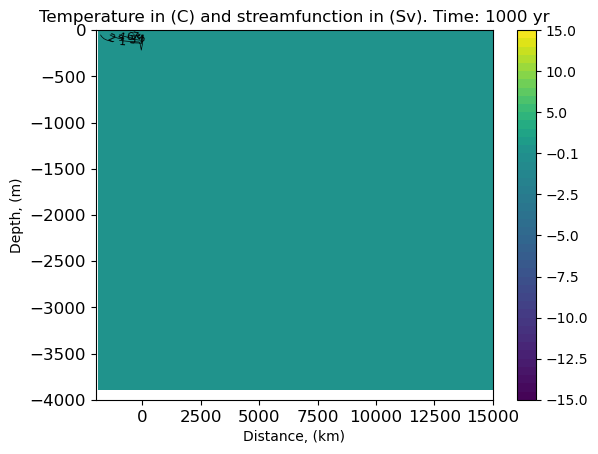

Saving: out.mat


In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

cc = np.concatenate([np.arange(-15, 0, 0.5), [-0.1], np.arange(1, 16)])
cf = plt.contourf(yp * 1e-3, zp, P.T * Lx * 1e-6, levels=cc, linestyles='--')
plt.colorbar(cf)
plt.clim(cc[0], cc[-1])

cc_b = np.arange(1, 11)
cb = plt.contour(yb * 1e-3, zb, B.T / 2e-4 / 10, levels=cc_b, colors='k', linewidths=0.5)
plt.clabel(cb, fmt='%1.0f', fontsize=8, colors='k')

plt.xlim(np.array([-l, Ly]) * 1e-3)
plt.ylim(np.array([-H, 0]))

plt.gca().tick_params(labelsize=12)
plt.xlabel('Distance, (km)')
plt.ylabel('Depth, (m)')
plt.title(f'Temperature in (C) and streamfunction in (Sv). Time: {round(t*dt/12/30/24/3600)} yr')

plt.show()

if do_save:
    print(f'Saving: {fnameOUT}')
    from scipy.io import savemat
    savemat(fnameOUT, {'P': P, 'B': B, 'b': b})
